# 04 — Pourquoi les clients se plaignent

**Objectif** — passer de la nomenclature produit (SARA, COMPTE) à une taxonomie
**causale**, exploitable pour décider quoi corriger et par qui.

| | |
|---|---|
| **Entrée** | périmètre d'analyse défini au notebook 03 |
| **Sorties** | `resultats/tables/04_familles_causales.csv`, `04_operateurs.csv`, `04_audit_non_classes.csv` + 2 figures |
| **Suite** | notebook 05 — récidive et charge |

**Ce que ce notebook établit**

1. Un motif domine tout : *l'argent a quitté le compte et n'est jamais arrivé*.
2. La classification par règles plafonne à ~59 % de rappel, et l'audit manuel
   montre que le reliquat relève très majoritairement **de familles déjà
   identifiées**. Les pourcentages produits ici sont donc des **planchers**.
3. Ce plafond est l'argument chiffré en faveur d'une classification apprise.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, texte, viz

viz.appliquer_charte()
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 110)

df = chargement.typer(chargement.charger_brut())
analyse = chargement.perimetre_analyse(df)
analyse["texte"] = texte.construire_texte(analyse)
base = analyse[texte.a_texte_exploitable(analyse["texte"])].copy()

print(f"Base d'analyse : {len(base):,} tickets ({len(base) / len(analyse) * 100:.1f} % du périmètre)")

Base d'analyse : 6,545 tickets (95.3 % du périmètre)


## 1. Pourquoi le type de ticket ne répond pas à la question

`ticket_type_name` est la catégorie choisie au dépôt. Elle dit dans quel produit
ranger le dossier, pas ce qui a dysfonctionné.

In [2]:
analyse["ticket_type_name"].value_counts().head(6).to_frame("effectif").assign(
    pct=lambda t: (t["effectif"] / len(analyse) * 100).round(1)
)

,effectif,pct
ticket_type_name,,
SARA,3970,57.8
COMPTE,2277,33.2
BENEFICIAIRE ERRONE,345,5.0
CARTE,90,1.3
ACCUEIL,59,0.9
CREDIT,52,0.8


« SARA » et « COMPTE » couvrent 86 % du volume. Savoir qu'une réclamation
concerne SARA ne dit ni ce qui a échoué, ni qui doit corriger. Il faut lire ce
que le client a écrit.

In [3]:
for t in base["texte"].head(5):
    print(" •", t[:160], "\n")

 • reclamation le 14.07.2026 a 18heures 35 minutes et 03 secondes j'ai effectue un transfert de 15000 de mon compte sara pour mon compte orangemoney. j'ai bien ete 

 • transfert vers orange non abouti 

 • beneficiary error i made a transaction of 10600 on the 26/06/2026 to [TEL] instead of [TEL] 

 • erreur de beneficiaire lors d'une transaction sur l'application sara money j'ai confondu le dernier chiffre de mon numero et le depot est alle ailleurs 

 • cela fait maintenant plusieurs jours que j'ai expose mon probleme sans toutefois avoir la moindre reponse a ma preoccupation. je me retrouve avec un compte au r 



## 2. Taxonomie causale

Six familles, **exclusives**, appliquées dans un ordre de priorité documenté
dans `src/reclamations/texte.py`. Chaque famille porte un **responsable de la
correction** : c'est ce qui rend la taxonomie actionnable. Deux familles de même
volume mais de responsables différents appellent des chantiers différents.

In [4]:
for code, libelle, _motif, responsable in texte.FAMILLES:
    print(f"{code:20s} {libelle:52s} -> {responsable}")

erreur_client        Erreur de saisie du client (mauvais bénéficiaire)    -> UX de l'application
debit_non_credit     Débité sans que le bénéficiaire soit crédité         -> Système (banque <-> opérateur)
acces_otp            Accès bloqué / OTP / authentification                -> Système (authentification)
debit_injustifie     Débit injustifié, doublé, ou frais contestés         -> Système (banque)
carte                Carte bancaire / distributeur                        -> Système (monétique)
demande_info         Demande d'information (pas une réclamation)          -> Hors périmètre réclamation


In [5]:
base["famille"] = texte.classer(base["texte"])
familles = texte.couverture(base["famille"])
chargement.sauver_table(familles, "04_familles_causales")
familles

C:\Users\agent_dri_02\Desktop\data_alan\reclamation\niv\src\reclamations\texte.py:180: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


  -> resultats\tables\04_familles_causales.csv


,libelle,responsable,effectif,pct
famille,,,,
debit_non_credit,Débité sans que le bénéficiaire soit crédité,Système (banque <-> opérateur),2911,44.5
non_classe,Non classé par les règles,Indéterminé,2677,40.9
erreur_client,Erreur de saisie du client (mauvais bénéficiaire),UX de l'application,421,6.4
debit_injustifie,"Débit injustifié, doublé, ou frais contestés",Système (banque),216,3.3
acces_otp,Accès bloqué / OTP / authentification,Système (authentification),161,2.5
carte,Carte bancaire / distributeur,Système (monétique),130,2.0
demande_info,Demande d'information (pas une réclamation),Hors périmètre réclamation,29,0.4


## 3. Lecture — et la précaution qui va avec

La famille *débité sans que le bénéficiaire soit crédité* est de loin la
première. Mais **40,9 % des textes ne sont classés par aucune règle**, et cette
ligne est volontairement conservée dans le tableau : la masquer donnerait une
répartition apparemment complète, calculée sur 59 % de la base.

  -> resultats\figures\04_familles_causales.png


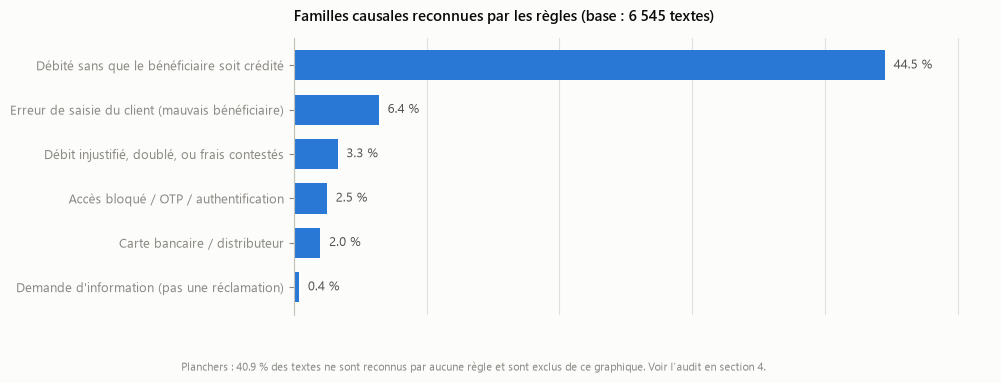

In [6]:
pct_non_classe = (base["famille"] == texte.NON_CLASSE).mean() * 100

fig, ax = plt.subplots(figsize=(9, 3.6))
a_montrer = familles[familles.index != texte.NON_CLASSE]
viz.barres_horizontales(
    a_montrer.set_index("libelle")["pct"],
    f"Familles causales reconnues par les règles (base : {len(base):,} textes)".replace(",", " "),
    unite=" %",
    ax=ax,
    format_valeur="{:.1f}",
)
viz.annoter_source(
    fig,
    f"Planchers : {pct_non_classe:.1f} % des textes ne sont reconnus par aucune règle "
    "et sont exclus de ce graphique. Voir l'audit en section 4.",
)
viz.sauver(fig, "04_familles_causales")
plt.show()

## 4. Audit manuel du reliquat — l'étape qui décide de la suite

Le taux de non-classés ne se commente pas, il s'audite. La question est binaire :
le reliquat est-il **une autre famille** (la taxonomie est incomplète) ou **la
même famille formulée autrement** (les règles sous-estiment une famille connue) ?
Les deux diagnostics mènent à des suites opposées.

L'échantillon est tiré avec une graine fixe : le décompte reporté ci-dessous
reste vérifiable à chaque exécution.

In [7]:
echantillon = texte.echantillon_non_classes(base["texte"], base["famille"], n=20, graine=3)
chargement.sauver_table(echantillon.rename("texte").to_frame(), "04_audit_non_classes")
for i, t in enumerate(echantillon, 1):
    print(f"{i:2d}. {t[:150]}")

  -> resultats\tables\04_audit_non_classes.csv
 1. echec d'un transfert le 25 novembre j'ai fait un transfert de 37000f cfa du compte bancaire vers sara malheureusement j'ai ete debite de 185000f cfa d
 2. svp j'aimerais savoir pourquoi on continue a debiter mon solde de temps en temps pourtant le gestionnaire m'avait rassure qu'on allait plus debite.
 3. reclamation retrait effectue par sara pour orange money. rien n'est arrive dans mon compte mais mon compte a ete debite
 4. hello please i have an issue my current account shows me negative 39000 o dont understand why?
 5. je reclame l'argent qui n'es jamais arrive depuis octobre
 6. 350.000 fcfa a ete debite de mon compte bancaire j'ai essaye le 25.06.2026 de faire a 2 reprises une transaction de 350.000 fcfa de mon compte afrilan
 7. erreur de calcul sur mon compte, solde negatif, s'il vous plait bien vouloir actualiser mon compte
 8. objet : reclamation concernant des transferts dargent vers mon compte sara money madame, monsieur

**Décompte manuel sur cet échantillon de 20** (relecture ligne à ligne, sur le
tirage de graine 3 affiché ci-dessus) :

| Famille réelle | Lignes | Nombre |
|---|---|---|
| Débité sans que le bénéficiaire soit crédité | 3, 5, 6, 8, 10, 13, 15, 17 | 8 |
| Débit injustifié / doublé | 1, 2, 4, 7, 9, 14, 19, 20 | 8 |
| Erreur de saisie du client | 12 | 1 |
| Carte / guichet automatique | 11 | 1 |
| Autre (dysfonctionnement applicatif) | 16, 18 | 2 |

Les formulations qui échappent aux règles sont des variantes des mêmes
incidents : « opération qui a échoué », « rien n'est arrivé », « débit sans
motif », « débité 2 fois », et les tournures anglaises (*« has failed »*,
*« I received no money »*).

> **Conclusion de l'audit — deux enseignements distincts.**
>
> 1. La **taxonomie est complète** : 18 des 20 textes relèvent d'une famille
>    déjà définie. Ce sont les *règles* qui sont insuffisantes, pas les catégories.
> 2. La famille *débit injustifié* est **très fortement sous-détectée** : elle ne
>    capte que 3,3 % par les règles alors qu'elle représente 40 % du reliquat.
>    Le double débit et le débit sans motif se disent de trop de façons pour
>    être attrapés par mots-clés.

### Estimation corrigée

En reportant la structure de l'audit sur l'ensemble du reliquat.

In [8]:
# Décompte de l'audit manuel ci-dessus, sur 20 textes non classés (graine 3).
# Modifier ces valeurs si l'échantillon est ré-audité avec une autre graine.
AUDIT_TAILLE = 20
AUDIT = {"debit_non_credit": 8, "debit_injustifie": 8}

part_non_classe = (base["famille"] == texte.NON_CLASSE).mean() * 100
print(f"Non classés par les règles : {part_non_classe:.1f} % de la base\n")

for code, n in AUDIT.items():
    regle = familles.loc[code, "pct"]
    corrige = regle + part_non_classe * (n / AUDIT_TAILLE)
    print(
        f"{texte.libelles()[code]:48s} règles {regle:5.1f} %  "
        f"+ reliquat {n}/{AUDIT_TAILLE}  ->  ~{corrige:.0f} %"
    )

total = sum(
    familles.loc[c, "pct"] + part_non_classe * (n / AUDIT_TAILLE) for c, n in AUDIT.items()
)
print(f"\n{'Cumul « l argent a été pris à tort »':48s} {'':22s}  ->  ~{total:.0f} %")

Non classés par les règles : 40.9 % de la base

Débité sans que le bénéficiaire soit crédité     règles  44.5 %  + reliquat 8/20  ->  ~61 %
Débit injustifié, doublé, ou frais contestés     règles   3.3 %  + reliquat 8/20  ->  ~20 %

Cumul « l argent a été pris à tort »                                     ->  ~81 %


> **Environ 6 réclamations sur 10** disent : *mon compte a été débité, le
> bénéficiaire n'a rien reçu.* En y ajoutant les débits injustifiés ou doublés,
> **environ 8 sur 10** portent sur de l'argent prélevé à tort ou jamais arrivé.

**Précaution.** Cette correction repose sur un audit de 20 textes : l'intervalle
de confiance à 95 % sur une proportion de 8/20 est d'environ ±21 points. C'est
un **ordre de grandeur**, pas une mesure.

C'est exactement pour cela que l'étape suivante du projet est une classification
apprise — pour remplacer cette extrapolation par une mesure, sur les 6 545
textes de la base.

## 5. Qui doit corriger ?

Regroupement des familles par responsable de la correction.

In [9]:
base["responsable"] = base["famille"].map(texte.responsables())
par_responsable = (
    base[base["famille"] != texte.NON_CLASSE]["responsable"]
    .value_counts()
    .to_frame("effectif")
)
par_responsable["pct_des_classes"] = (
    par_responsable["effectif"] / par_responsable["effectif"].sum() * 100
).round(1)
chargement.sauver_table(par_responsable, "04_par_responsable")
par_responsable

  -> resultats\tables\04_par_responsable.csv


,effectif,pct_des_classes
responsable,,
Système (banque <-> opérateur),2911,75.3
UX de l'application,421,10.9
Système (banque),216,5.6
Système (authentification),161,4.2
Système (monétique),130,3.4
Hors périmètre réclamation,29,0.7


**Point d'action isolé par cette lecture.** L'erreur de saisie du bénéficiaire
est la seule famille dont la correction ne dépend pas d'un diagnostic technique :
afficher le nom du titulaire avant validation du transfert — ce que font déjà
les opérateurs de mobile money — supprime le motif à la source. C'est le seul
gisement que ces données permettent à la fois de chiffrer et de corriger sans
donnée supplémentaire.

## 6. Opérateur mis en cause et sens du flux

Sur les tickets de la famille dominante uniquement.

In [10]:
dominante = base[base["famille"] == "debit_non_credit"]["texte"]

operateurs = texte.detecter(dominante, texte.OPERATEURS)
chargement.sauver_table(operateurs, "04_operateurs")
operateurs

  -> resultats\tables\04_operateurs.csv


C:\Users\agent_dri_02\Desktop\data_alan\reclamation\niv\src\reclamations\texte.py:273: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m = texte.str.contains(motif, regex=True, na=False)


,mentions,pct,base
motif,,,
Orange Money,1408,48.4,2911
MTN MoMo,284,9.8,2911
Autre banque,13,0.4,2911


In [11]:
flux = texte.detecter(dominante, texte.SENS_FLUX)
chargement.sauver_table(flux, "04_sens_flux")
flux

  -> resultats\tables\04_sens_flux.csv


C:\Users\agent_dri_02\Desktop\data_alan\reclamation\niv\src\reclamations\texte.py:273: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  m = texte.str.contains(motif, regex=True, na=False)


,mentions,pct,base
motif,,,
Sortant (SARA -> mobile money),1030,35.4,2911
Entrant (banque/MoMo -> SARA),146,5.0,2911


**Deux pistes, à ne pas confondre avec des conclusions.**

- Le sens **sortant** (SARA → mobile money) est cité bien plus souvent que
  l'entrant. La casse semble concentrée sur une direction du flux.
- Orange Money est cité plusieurs fois plus que MTN. **Cet écart n'est pas
  interprétable en l'état** : il est confondu avec les parts de marché
  respectives des deux opérateurs dans la base client. Un décompte de mentions
  n'est pas un taux de défaillance.

> Pour transformer ces deux pistes en diagnostic, il faut le **dénominateur** :
> le volume de transactions par opérateur et par sens de flux. Il est absent de
> cet export — voir la conclusion du notebook 06.

## 7. Exposition financière — ordre de grandeur

Les montants ne sont fiables ni en agrégat ni en moyenne (valeurs négatives,
nulles, et un amas artificiel entre 690 M et 700 M XAF). On ne retient que des
montants plausibles, et on lit la **médiane**, insensible aux valeurs extrêmes.

In [12]:
mt = chargement.montants_plausibles(base)
expo = mt.groupby("famille")["montant"].agg(
    tickets="count", mediane="median", total="sum"
).sort_values("tickets", ascending=False)
chargement.sauver_table(expo.round(0), "04_exposition_par_famille")
expo.round(0)

  -> resultats\tables\04_exposition_par_famille.csv


,tickets,mediane,total
famille,,,
debit_non_credit,2812,50000.0,377773488.0
non_classe,2260,50000.0,400069260.0
erreur_client,237,50000.0,23304100.0
debit_injustifie,196,40000.0,25143994.0
carte,104,100000.0,20239398.0
acces_otp,64,60000.0,16220771.0
demande_info,21,40000.0,6190707.0


> **Aucun de ces totaux ne doit être communiqué comme un chiffre officiel.** Ils
> ne portent que sur les tickets dont le montant est renseigné et plausible, et
> le champ n'a pas été validé par le métier. Ils servent à hiérarchiser les
> familles entre elles, pas à chiffrer un préjudice.